## **Question 1 : vérifier que le GPU est bien sélectionné**


In [55]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


## **Instruction 1 : Installation de pytorch lightning**

In [56]:
!pip install pytorch_lightning torchinfo

## **Question 2 : connecter votre notebook à la plateforme WanDB**:

In [57]:
import wandb
wandb.login(key="9414e8ff95ebd7016321b49a7cd54fac7c75fd9d")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True

## **Instruction 3 : Téléchargement du jeu de données d'entraînement : railway-construction-50** ##

In [58]:
import os
import urllib.request
import zipfile

# Supprimer un dossier (équivalent de `rm -rf`)
if os.path.exists("sample_data"):
    import shutil
    shutil.rmtree("sample_data")

# Télécharger le fichier (équivalent de `wget`)
url = "https://nextcloud.ig.umons.ac.be/s/zBCAj6GFJQjA3fz/download/railway-construction-50.zip"
file_name = "railway-construction-50.zip"
urllib.request.urlretrieve(url, file_name)

# Créer un dossier (équivalent de `mkdir -p`)
os.makedirs("dataset", exist_ok=True)

# Décompresser le fichier (équivalent de `unzip`)
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# Supprimer le fichier ZIP après extraction (équivalent de `rm`)
os.remove(file_name)

## **Instruction 4 : Importation des libraries** ##

In [59]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler, Subset
import matplotlib.pyplot as plt
import cv2
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms.v2 as transforms
from tqdm import tqdm
from torchsummary import summary
from torchmetrics import Accuracy
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, TensorBoardLogger , CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
import pandas as pd

# **Instruction 5 : définir les paramètres d'entrainement "Hyper-paramètres"**

In [60]:
# Hyperparameters
dataset_path = r"dataset/railway-construction-50/"  #@param ["dataset/railway-construction-50/","dataset/railway-construction-100/","dataset/railway-construction-big/"] {type:"string"}
batch_size = 32 #@param [8,16,32,64,128,256] {type:"raw"}
train_split = 0.8 #@param {type:"slider", min:0.5, max:0.9, step:0.05}
val_split = 0.1 #@param {type:"slider", min:0.1, max:0.5, step:0.05}
epochs = 5 #@param [1,5, 10,20,50,100,200] {type:"raw"}
learning_rate = 0.01  #@param [0.1, 0.01,0.02,0.05,0.001,0.002,0.005] {type:"raw"}
img_size = 224
num_classes = 4
LOG_DIR = r"logs"

## **Question 3 : analyser attentivement la classe «Model» avant de la compléter**

In [61]:
print(models.vgg16())                         # Analyser et visualiser l'architecture du modèle pré-entrainé

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [62]:
class Model(pl.LightningModule):
    def __init__(self, num_classes=4, learning_rate=3e-4):
        super().__init__()
        self.model = models.vgg16(pretrained=True)                # Récupère un VGG16 préentraîné
        for param in self.model.features.parameters():            # Gèle les couches de features pour ne pas les réentraîner
            param.requires_grad = False
        self.model.classifier[6] = nn.Linear(4096, num_classes)   # Modifie la dernière couche pour correspondre au nombre de classes
        self.criterion = nn.CrossEntropyLoss()                    # Fonction d'erreur : cross entropy
        self.learning_rate = learning_rate                        # Taux d'apprentissage passé en paramètre
        self.num_classes = num_classes                            # Nombre de classes pour la classification
        self.test_accuracy = Accuracy(task="multiclass", num_classes=num_classes)  # Métrique de précision pour le test
        self.val_accuracy = Accuracy(task="multiclass", num_classes=num_classes)   # Métrique de précision pour la validation
        self.train_accuracy = Accuracy(task="multiclass", num_classes=num_classes) # Métrique de précision pour l'entraînement

    def forward(self, x):
        return self.model(x)                                      # Passe les entrées à travers le modèle

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)  # Extraire les classes prédites
        acc = self.train_accuracy(predicted, labels)  # Correction : utiliser train_accuracy ici
        self.log_dict({'train_loss': loss, "train_acc": acc}, on_step=True, prog_bar=True, logger=True, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        pass  # Rien à faire ici pour l'instant

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)  # Extraire les classes prédites
        acc = self.val_accuracy(predicted, labels)
        self.log_dict({'val_loss': loss, "val_acc": acc}, on_step=False, prog_bar=True, logger=True, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        pass  # Rien à faire ici pour l'instant

    def test_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)  # Extraire les classes prédites
        acc = self.test_accuracy(predicted, labels)
        self.log_dict({'test_loss': loss, "test_acc": acc}, on_step=True, prog_bar=True, logger=True, on_epoch=True)
        return loss

    def on_test_end(self):
        pass  # Rien à faire ici pour l'instant

    def configure_optimizers(self):
        optimizer = optim.Adam(self.model.classifier.parameters(), lr=self.learning_rate)  # Optimiseur Adam sur la couche classifier
        return optimizer

## **Instruction 6 : fonction d'affichage des images** ##

In [63]:
def display_class_images(class_path):
  import glob
  import matplotlib.image as mpimg
  images = []
  for img_path in glob.glob(class_path):
      images.append(mpimg.imread(img_path))
  plt.figure(figsize=(14,12))
  columns = 4
  for i, img in enumerate(images):
      if (i<=4):
        img=cv2.resize(img, (256,256))
        plt.subplot(5, 5, i + 1)
        plt.imshow(img)

## **Question 4 : afficher quelques images de chaque classe**

Affichage des images pour la classe : excavator


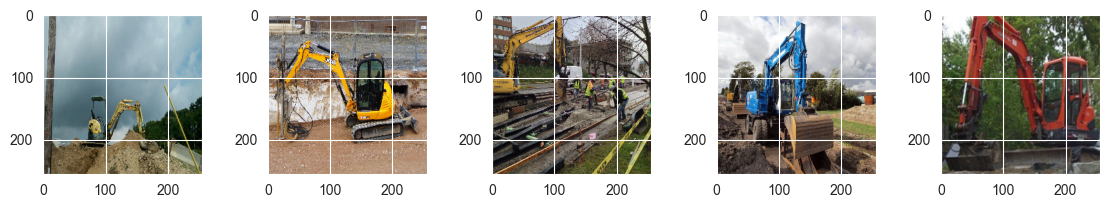

Affichage des images pour la classe : train


<Figure size 1400x1200 with 0 Axes>

Affichage des images pour la classe : train_tracks


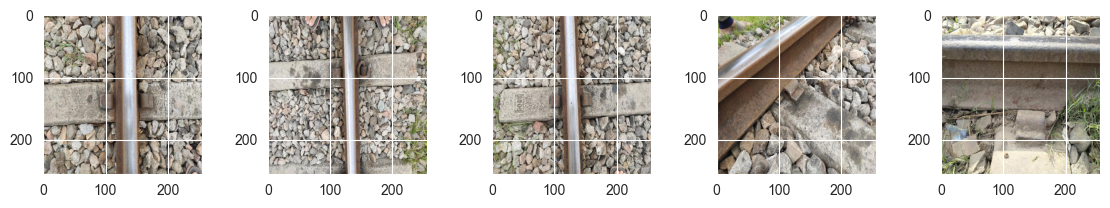

Affichage des images pour la classe : workers


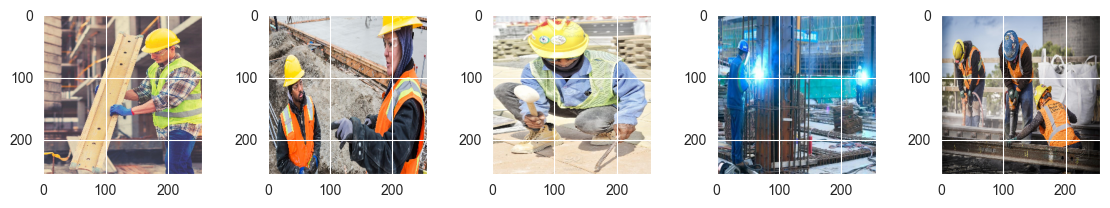

In [64]:
dataset_classes = os.listdir(dataset_path)  # Liste des sous-dossiers (classes) dans dataset_path
for class_name in dataset_classes:
    class_path = os.path.join(dataset_path, class_name, "*.jpg")  # Chemin vers les images JPG de la classe
    print(f"Affichage des images pour la classe : {class_name}")
    display_class_images(class_path)  # Appel de la fonction pour chaque classe
    plt.show()  # Affiche la figure pour chaque classe

## **Instruction 7 : Fonction de divison des données et création des tenseurs/dataloaders**

In [65]:
def create_data_loaders(dataset_path, batch_size, train_split, val_split, img_size):
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(img_size),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor()
    ])

    # Load the full dataset (without transforms initially)
    full_dataset = datasets.ImageFolder(dataset_path)

    dataset_size = len(full_dataset)
    indices = list(range(dataset_size))
    np.random.shuffle(indices)

    # Split indices
    train_end = int(train_split * dataset_size)
    val_end = train_end + int(val_split * dataset_size)

    train_indices = indices[:train_end]
    val_indices = indices[train_end:val_end]
    test_indices = indices[val_end:]

    # Create separate dataset subsets with corresponding transformations
    train_dataset = Subset(datasets.ImageFolder(dataset_path, transform=train_transform), train_indices)
    val_dataset = Subset(datasets.ImageFolder(dataset_path, transform=eval_transform), val_indices)
    test_dataset = Subset(datasets.ImageFolder(dataset_path, transform=eval_transform), test_indices)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


## **Question 5 : céer les data loaders (train, val, test) avec la fonction create_data_loaders**

In [66]:
train_loader, val_loader, test_loader = create_data_loaders(
    dataset_path=dataset_path,
    batch_size=batch_size,
    train_split=train_split,
    val_split=val_split,
    img_size=img_size
)
# Vérification rapide des tailles des datasets
print(f"Nombre de batches dans train_loader : {len(train_loader)} (taille totale : {len(train_loader.dataset)})")
print(f"Nombre de batches dans val_loader : {len(val_loader)} (taille totale : {len(val_loader.dataset)})")
print(f"Nombre de batches dans test_loader : {len(test_loader)} (taille totale : {len(test_loader.dataset)})")

Nombre de batches dans train_loader : 5 (taille totale : 160)
Nombre de batches dans val_loader : 1 (taille totale : 20)
Nombre de batches dans test_loader : 1 (taille totale : 20)


## **Question 6 : compléter le code (SGD avec lr='0.01') et lancer l'entrainement**

In [67]:
wandb_logger = WandbLogger(
    project="Railway-construction-safety",
    name="efficientnet_BD50",  # Note : le nom indique EfficientNet, mais nous utilisons VGG16 ici
    log_model=True,
)

# Initialize model
model = Model(num_classes=num_classes, learning_rate=0.01)  # Initialisation avec lr=0.01

# Initialize CsvLogger
csv_logger = CSVLogger(LOG_DIR, name="cnn1", version='')

# Initialize Trainer
trainer = pl.Trainer(
    max_epochs=epochs,
    accelerator="auto",
    logger=[wandb_logger, csv_logger],
)

# Train the model
trainer.fit(model, train_loader, val_loader)  # Lancement de l'entraînement avec train_loader et val_loader

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type               | Params | Mode 
--------------------------------------------------------------
0 | model          | VGG                | 134 M  | train
1 | criterion      | CrossEntropyLoss   | 0      | train
2 | test_accuracy  | MulticlassAccuracy | 0      | train
3 | val_accuracy   | MulticlassAccuracy | 0      | train
4 | train_accuracy | MulticlassAccuracy | 0      | train
--------------------------------------------------------------
119 M     Trainable params
14.7 M    Non-trainable params
134 M     Total params
537.108   Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


## **Instruction 8 : fonction de visulisation des courbes d'entrainement avec plot**

In [68]:
def plot_metrics(log_folder):
  import pandas as pd
  import matplotlib.pyplot as plt

  # Load the CSV file generated by CSVLogger
  df = pd.read_csv(f'{LOG_DIR}/{log_folder}/metrics.csv')
  train_df = df[df['train_loss_epoch'].notna()]
  val_df = df[df['val_loss'].notna()]

  # Plot training loss
  plt.plot(train_df['epoch'], train_df['train_loss_epoch'], label='Train Loss')
  plt.plot(val_df['epoch'], val_df['val_loss'], label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training & Validation Loss')
  plt.legend()
  plt.grid(True)
  plt.show()

  # Plot training accuracy
  plt.plot(train_df['epoch'], train_df['train_acc_epoch'], label='Train Acc')
  plt.plot(val_df['epoch'], val_df['val_acc'], label='Val Acc')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training & Validation Accuracy')
  plt.legend()
  plt.grid(True)
  plt.show()

## **Question 7 : Afficher vos courbes d'entrainement avec la fonction "plot_metrics"**

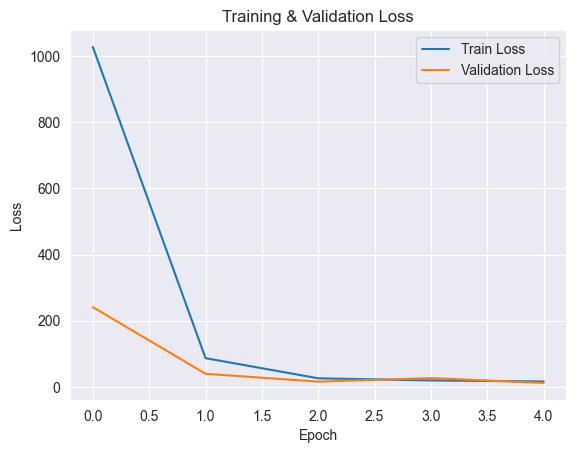

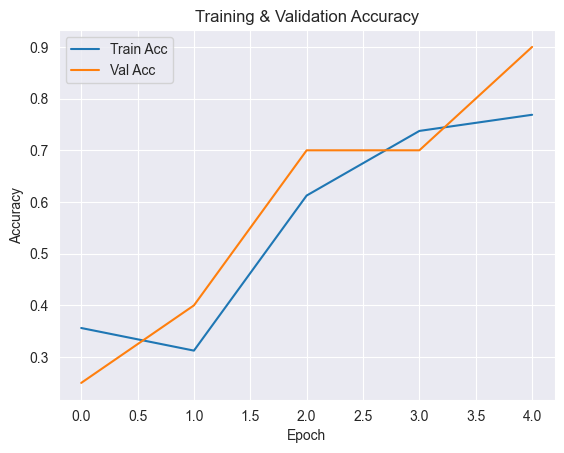

In [69]:
plot_metrics("cnn1")

## **Question 8 :vérifier/interpréter les courbes d'entraînement de votre modèle via Wandb ou plot**

https://wandb.ai/maximilien003-universit-de-mons/Railway-construction-safety?nw=nwusermaximilien003

## **Question 9 : évaluer votre premier modèle avec les données de test**

In [70]:
trainer.test(model, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_acc_epoch          0.800000011920929
     test_loss_epoch         17.06847381591797
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss_epoch': 17.06847381591797, 'test_acc_epoch': 0.800000011920929}]

## **Instruction 9 : exporter le modèle en format torchscript pour la soumission Kaggle**

In [71]:
jit_model = model.to_torchscript()
torch.jit.save(jit_model, 'model_jitb.pth')

## **Instruction 10 : télécharger la base de données test non labelisée**

In [72]:
import os
import urllib.request
import zipfile
import shutil

# Télécharger le fichier (équivalent de `wget`)
url = "https://nextcloud.ig.umons.ac.be/s/imNGnwZtSEnYJNL/download/test_no_classes.zip"
file_name = "test_no_classes.zip"
urllib.request.urlretrieve(url, file_name)
print(f"Téléchargement terminé : {file_name}")

# Créer le dossier de destination s'il n'existe pas
extract_folder = "test_data"
os.makedirs(extract_folder, exist_ok=True)

# Décompresser le fichier ZIP (équivalent de `unzip`)
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)
print(f"Fichier extrait dans : {extract_folder}")

# Supprimer le fichier ZIP après extraction (équivalent de `rm`)
os.remove(file_name)
print(f"Fichier supprimé : {file_name}")

# Définir le chemin du dossier de test
test_folder_path = os.path.join(extract_folder, "test")
print(f"Chemin du dossier de test : {test_folder_path}")

Téléchargement terminé : test_no_classes.zip
Fichier extrait dans : test_data
Fichier supprimé : test_no_classes.zip
Chemin du dossier de test : test_data\test


## **Instruction 11 : normalisation et transformation des données de test**

In [73]:
test_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor()
    ])

C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


## **Instruction 12 : fonction de génération des prédictions pour soumission au challenge Kaggle**

In [75]:
def predict_folder(model, folder_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()


    predictions = []
    filenames = []

    for img_path in os.listdir(folder_path):
        with torch.no_grad():
            # Load and preprocess image
            image = Image.open(folder_path+'/'+img_path).convert('RGB')
            image = test_transform(image).unsqueeze(0).to(device)

            # Get prediction
            output = model(image)
            _, predicted = output.max(1)

            predictions.append(predicted.item())
            filenames.append(img_path)

    # Create submission dataframe
    submission_df = pd.DataFrame({
        'ID': filenames,
        'Label': predictions
    })

    # Save to CSV
    submission_df.to_csv('submissionbig.csv', index=False)
    return submission_df

## **Question 10 : appliquer cette fonction pour générer les prédiction csv à soumettre via Kaggle**

In [76]:
submission = predict_folder(jit_model, test_folder_path)

## **Question 11 : modifier le code pour appliquer l'earlystopping et chekpoint (Chap. 5)**

In [77]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

# Initialiser le modèle
model = Model(num_classes=num_classes, learning_rate=0.01)

# Définir les callbacks
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',  # Surveiller la perte de validation
    dirpath='checkpoints/',  # Dossier où sauvegarder les checkpoints
    filename='best-model-{epoch:02d}-{val_loss:.2f}',  # Nom du fichier
    save_top_k=1,  # Sauvegarder seulement le meilleur modèle
    mode='min'  # Minimiser la perte de validation
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Surveiller la perte de validation
    patience=3,  # Nombre d'époques sans amélioration avant d'arrêter
    mode='min'  # Arrêter lorsque la perte de validation cesse de diminuer
)

# Initialiser le Trainer avec les callbacks
trainer = pl.Trainer(
    max_epochs=epochs,
    accelerator="auto",
    logger=[wandb_logger, csv_logger],
    callbacks=[checkpoint_callback, early_stopping_callback]  # Ajouter les callbacks
)

# Entraîner le modèle
trainer.fit(model, train_loader, val_loader)

# Tester le modèle avec les données de test
trainer.test(model, test_loader)

# Exporter le modèle en TorchScript
jit_model = model.to_torchscript()
torch.jit.save(jit_model, 'model_jitb.pth')

# Définir les transformations pour les données de test
test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor()
])

# Générer les prédictions et créer le fichier submission.csv
submission = predict_folder(jit_model, test_folder_path)
print("Fichier submission.csv généré avec succès.")

C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type               | Params | Mode 
-----------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:310: The number of training batches (5) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_epochs=5` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_acc_epoch         0.8500000238418579
     test_loss_epoch        2.1584224700927734
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Fichier submission.csv généré avec succès.


## **Question 12 : modifier le code pour calculer la matrice de confusion en phase de test**

C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:310: The number of training batches (5) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\maxim\OneDrive\Documents\UMONS\BAB3\Q2 - Intelligence Artificielle\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

Matrice de confusion :
tensor([[3, 0, 0, 0],
        [1, 6, 0, 0],
        [0, 0, 4, 0],
        [2, 0, 0, 4]], device='cuda:0')


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

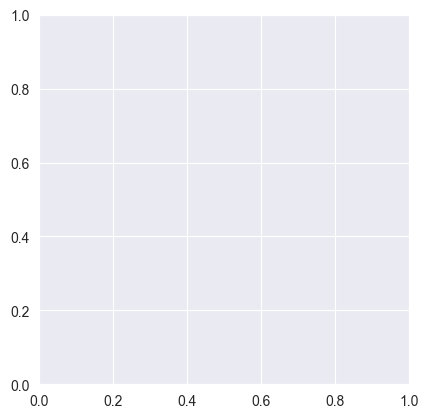

In [82]:
from torchmetrics.classification import MulticlassConfusionMatrix

# Redéfinition de la classe Model avec la matrice de confusion
class Model(pl.LightningModule):
    def __init__(self, num_classes=4, learning_rate=3e-4):
        super().__init__()
        self.model = models.vgg16(pretrained=True)
        for param in self.model.features.parameters():
            param.requires_grad = False
        self.model.classifier[6] = nn.Linear(4096, num_classes)
        self.criterion = nn.CrossEntropyLoss()
        self.learning_rate = learning_rate
        self.num_classes = num_classes
        self.test_accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.train_accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        # Ajout de la matrice de confusion pour la phase de test
        self.confusion_matrix = MulticlassConfusionMatrix(num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        acc = self.train_accuracy(predicted, labels)
        self.log_dict({'train_loss': loss, "train_acc": acc}, on_step=True, prog_bar=True, logger=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        acc = self.val_accuracy(predicted, labels)
        self.log_dict({'val_loss': loss, "val_acc": acc}, on_step=False, prog_bar=True, logger=True, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        acc = self.test_accuracy(predicted, labels)
        self.log_dict({'test_loss': loss, "test_acc": acc}, on_step=True, prog_bar=True, logger=True, on_epoch=True)
        # Mise à jour de la matrice de confusion
        self.confusion_matrix.update(predicted, labels)
        return loss

    def on_test_epoch_end(self):
        # Calculer et afficher la matrice de confusion
        cm = self.confusion_matrix.compute()
        print("Matrice de confusion :")
        print(cm)

        # Visualisation avec Matplotlib
        fig, ax = plt.subplots()
        cm_plot = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title("Matrice de confusion")
        plt.colorbar(cm_plot)
        tick_marks = np.arange(self.num_classes)
        plt.xticks(tick_marks, range(self.num_classes))
        plt.yticks(tick_marks, range(self.num_classes))
        plt.xlabel("Prédictions")
        plt.ylabel("Vérités")
        plt.show()

        # Réinitialiser la matrice pour le prochain test
        self.confusion_matrix.reset()

    def configure_optimizers(self):
        optimizer = optim.Adam(self.model.classifier.parameters(), lr=self.learning_rate)
        return optimizer


# Initialiser le modèle
model = Model(num_classes=num_classes, learning_rate=0.01)

# Définir les callbacks
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath='checkpoints/',
    filename='best-model-{epoch:02d}-{val_loss:.2f}',
    save_top_k=1,
    mode='min'
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    mode='min'
)

# Initialiser le Trainer avec les callbacks
trainer = pl.Trainer(
    max_epochs=epochs,
    accelerator="auto",
    callbacks=[checkpoint_callback, early_stopping_callback]
)

# Entraîner le modèle
trainer.fit(model, train_loader, val_loader)

# Tester le modèle avec les données de test (affichera la matrice de confusion)
trainer.test(model, test_loader)

# Exporter le modèle en TorchScript
jit_model = model.to_torchscript()
torch.jit.save(jit_model, 'model_jitb.pth')

# Définir les transformations pour les données de test
test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor()
])

# Générer les prédictions et créer le fichier submission.csv
submission = predict_folder(jit_model, test_folder_path)
print("Fichier submission.csv généré avec succès.")